In [64]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [ ]:
def load_all_csvs(csv_paths: List[str]) -> pd.DataFrame:
        """Load and combine multiple experiment CSVs."""
        dfs = []
        for path in csv_paths:
            df = pd.read_csv(path, index_col=0)
            df['source_file'] = Path(path).parent.name
            dfs.append(df)

            combined = pd.concat(dfs, ignore_index=True)
                
        return combined

In [22]:
import matplotlib.pyplot as plt

def plot_gap_vs_intervals(df):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

    # Unique gap sizes
    gap_sizes = sorted(df['gap_size_range'].unique())
    
    for g in gap_sizes:
        subset = df[df['gap_size_range'] == g]
        
        x = subset['num_intervals']
        y_time = subset['sum_time_mean']
        y_cov = subset['result_coverage_mean']
        yerr_time = subset['sum_time_std']

        ax1.errorbar(x, y_time, yerr=yerr_time, fmt='o-', label=f'gap={g}')
        ax2.plot(x, y_cov, 'o-', label=f'gap={g}')

    ax1.set_xlabel("Num Intervals")
    ax1.set_ylabel("Sum Time (ms)")
    ax1.set_title("Time vs Num Intervals")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.set_xlabel("Num Intervals")
    ax2.set_ylabel("Result Coverage")
    ax2.set_title("Coverage vs Num Intervals")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [65]:
# plot_gap_vs_intervals(df)

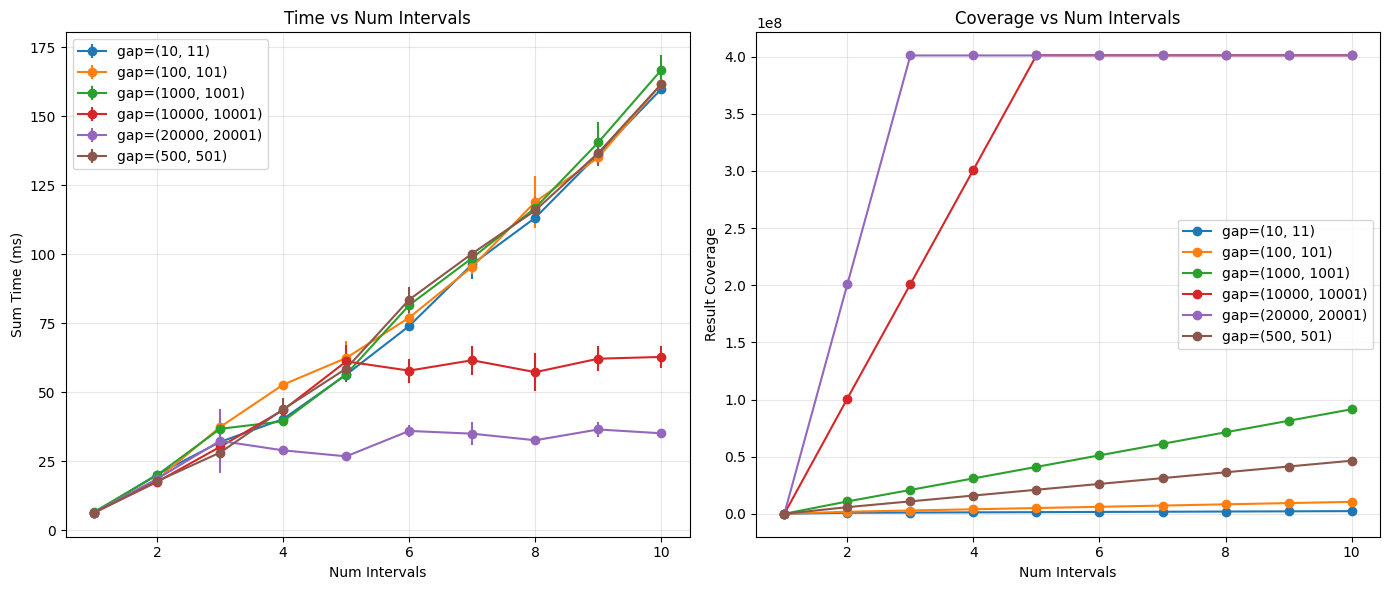

In [24]:
paths = ['data/results/2276863277/ni_gap_10k/ni_gap_red15_10_sweep/results_sd2276863277.csv']
df = load_all_csvs(paths)
plot_gap_vs_intervals(df)

In [171]:
paths2 = ['data/results/2277254639/ni_gap_10k/ni_gap_red15_10_sweep//results_sd2277254639.csv', 'data/results/2277254639/ni_gap_10k/ni_gap_red10_5_sweep//results_sd2277254639.csv', 'data/results/2277254639/ni_gap_10k/ni_gap_red4_2_sweep//results_sd2277254639.csv', 'data/results/2277254639/ni_gap_10k/ni_gap_red9_3_sweep//results_sd2277254639.csv', 'data/results/2277254639/ni_gap_10k/ni_gap_red5_2_sweep//results_sd2277254639.csv', 'data/results/2277254639/ni_gap_10k/ni_gap_red3_1_sweep//results_sd2277254639.csv', 'data/results/2277254639/ni_gap_10k/ni_gap_red1_1_sweep//results_sd2277254639.csv']
df = load_all_csvs(paths2)

df = df.sort_values('gap_size_range')
df['gap_size_range_tuple'] = df['gap_size_range'].apply(ast.literal_eval)
df['reduce_triggerSz_sizeLim_tuple'] = df['reduce_triggerSz_sizeLim'].apply(ast.literal_eval)
df

,master_seed,data_type,num_trials,dataset_size,uncertain_ratio,interval_size_range,mult_size_range,num_intervals,gap_size,interval_width,num_intervals_range,gap_size_range,interval_width_range,reduce_triggerSz_sizeLim,independent_variable,min_time_mean,min_time_std,max_time_mean,max_time_std,sum_time_mean,sum_time_std,sumtest_time_mean,sumtest_time_std,reduce_calls_mean,max_interval_count_mean,total_interval_count_mean,combine_calls_mean,result_size_mean,result_coverage_mean,source_file,gap_size_range_tuple,reduce_triggerSz_sizeLim_tuple
0,2277254639,set,5,10000,0.0,"(1, 50000)","(1, 5)",1,NaN,NaN,NaN,"(10, 11)","(2, 15)","(15, 10)",num_intervals,8.9960,0.445754,9.5556,0.832447,6.2902,0.127134,6.7058,0.300006,0.0,1.0,10000.0,10000.0,1.0,79984.2,ni_gap_red15_10_sweep,"(10, 11)","(15, 10)"
189,2277254639,set,5,10000,0.0,"(1, 50000)","(1, 5)",10,NaN,NaN,NaN,"(10, 11)","(2, 15)","(9, 3)",num_intervals,17.3238,0.387089,17.2082,0.722485,32.6004,4.187783,29.9808,1.334912,9999.0,100.0,300050.0,10000.0,3.0,1859576.2,ni_gap_red9_3_sweep,"(10, 11)","(9, 3)"
361,2277254639,set,5,10000,0.0,"(1, 50000)","(1, 5)",2,NaN,NaN,NaN,"(10, 11)","(2, 15)","(1, 1)",num_intervals,12.4766,1.543077,11.1674,0.403586,9.5168,1.189468,7.6078,0.126376,9999.0,4.0,20002.0,10000.0,1.0,259748.4,ni_gap_red1_1_sweep,"(10, 11)","(1, 1)"
362,2277254639,set,5,10000,0.0,"(1, 50000)","(1, 5)",3,NaN,NaN,NaN,"(10, 11)","(2, 15)","(1, 1)",num_intervals,12.8252,0.529741,11.7676,0.260976,10.1022,0.504531,8.3164,0.165411,9999.0,9.0,30006.0,10000.0,1.0,439672.0,ni_gap_red1_1_sweep,"(10, 11)","(1, 1)"
363,2277254639,set,5,10000,0.0,"(1, 50000)","(1, 5)",4,NaN,NaN,NaN,"(10, 11)","(2, 15)","(1, 1)",num_intervals,15.1056,1.414809,25.6310,23.970603,11.4028,2.121440,11.4898,3.689577,9999.0,16.0,40012.0,10000.0,1.0,619780.8,ni_gap_red1_1_sweep,"(10, 11)","(1, 1)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206,2277254639,set,5,10000,0.0,"(1, 50000)","(1, 5)",7,NaN,NaN,NaN,"(500, 501)","(2, 15)","(9, 3)",num_intervals,21.0380,0.751133,22.6568,0.273941,24.9928,2.734211,20.0766,0.568303,9999.0,49.0,210014.0,10000.0,3.0,30793450.2,ni_gap_red9_3_sweep,"(500, 501)","(9, 3)"
207,2277254639,set,5,10000,0.0,"(1, 50000)","(1, 5)",8,NaN,NaN,NaN,"(500, 501)","(2, 15)","(9, 3)",num_intervals,21.6548,0.436425,25.1398,0.712015,25.6182,2.820058,23.4218,1.865839,9999.0,64.0,240024.0,10000.0,3.0,35879977.8,ni_gap_red9_3_sweep,"(500, 501)","(9, 3)"
208,2277254639,set,5,10000,0.0,"(1, 50000)","(1, 5)",9,NaN,NaN,NaN,"(500, 501)","(2, 15)","(9, 3)",num_intervals,22.7316,0.360851,27.2992,0.612443,28.7988,2.560250,26.1068,0.884009,9999.0,81.0,270036.0,10000.0,3.0,40881099.2,ni_gap_red9_3_sweep,"(500, 501)","(9, 3)"
89,2277254639,set,5,10000,0.0,"(1, 50000)","(1, 5)",10,NaN,NaN,NaN,"(500, 501)","(2, 15)","(10, 5)",num_intervals,24.1872,1.206427,29.6448,0.958007,55.3108,1.870686,53.7598,1.185930,9999.0,100.0,500010.0,10000.0,5.0,46124369.4,ni_gap_red10_5_sweep,"(500, 501)","(10, 5)"


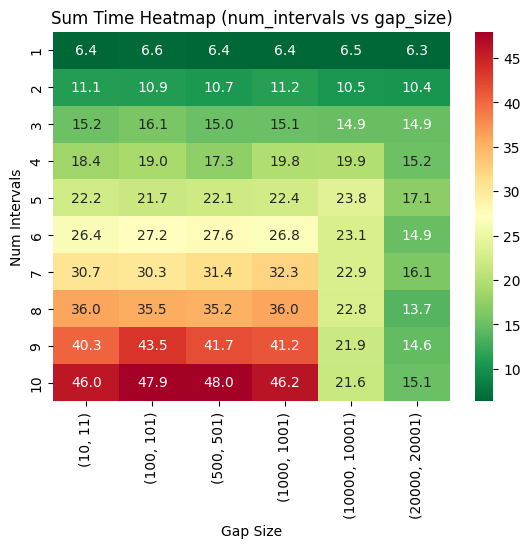

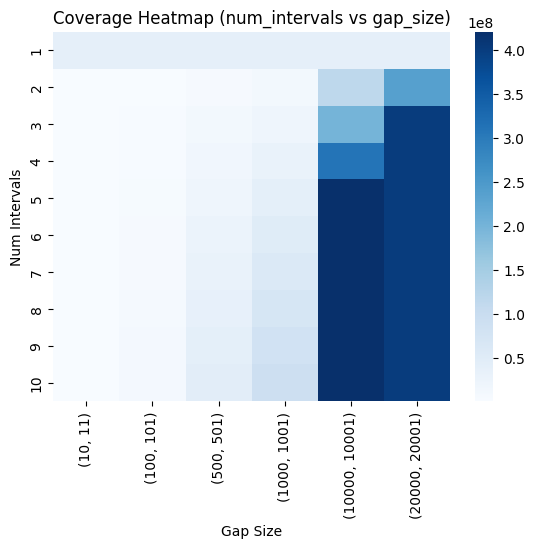

In [136]:
import seaborn as sns

# Time heatmap
time_pivot = df.pivot_table(values='sum_time_mean', index='num_intervals', columns='gap_size_range')
time_pivot.sort_index(axis=0)

sns.heatmap(time_pivot, annot=True, fmt=".1f", cmap='RdYlGn_r')
plt.title("Sum Time Heatmap (num_intervals vs gap_size)")
plt.xlabel("Gap Size")
plt.ylabel("Num Intervals")
plt.show()

# Coverage heatmap
cov_pivot = df.pivot_table(values='result_coverage_mean', index='num_intervals', columns='gap_size_range')
cov_pivot.sort_index(axis=0)
sns.heatmap(cov_pivot, fmt=".2f", cmap='Blues')
plt.title("Coverage Heatmap (num_intervals vs gap_size)")
plt.xlabel("Gap Size")
plt.ylabel("Num Intervals")
plt.show()

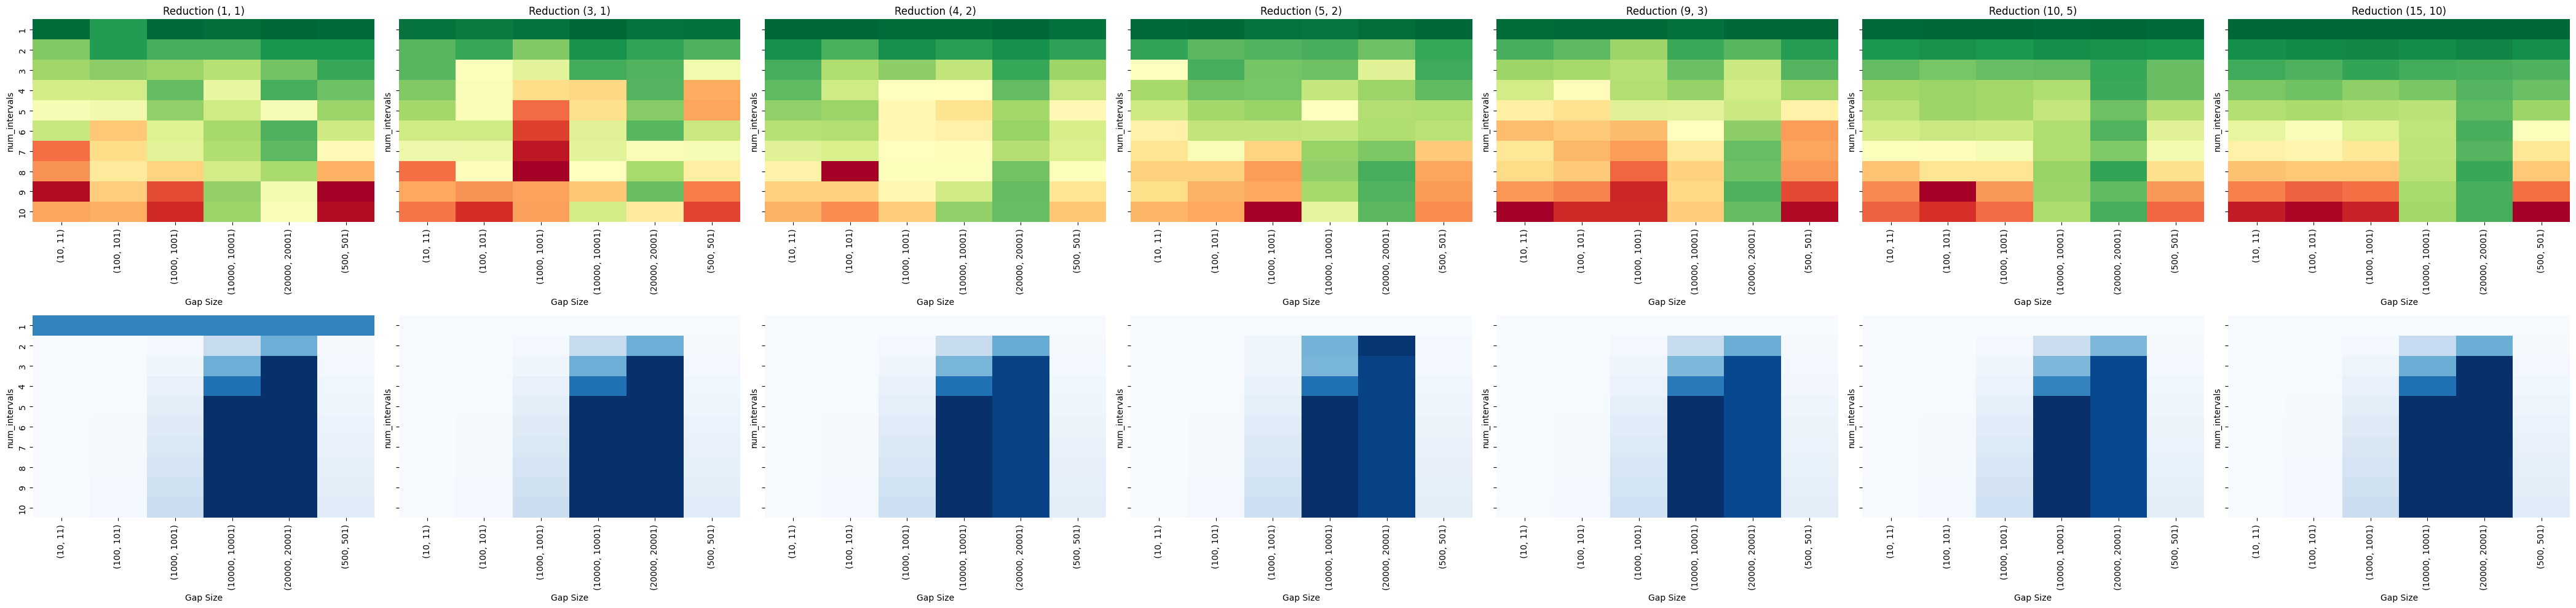

In [188]:

reds = sorted(df["reduce_triggerSz_sizeLim_tuple"].unique())
n = len(reds)

fig, ax = plt.subplots(2, n, figsize=(6*n, 10), sharey=True)
for i, red in enumerate(reds):
    ax_time = ax[0, i]
    subdf = df[df["reduce_triggerSz_sizeLim_tuple"] == red]
    
    pivot = subdf.pivot_table(
        values="sum_time_mean",
        index="num_intervals",
        columns="gap_size_range"
    )
    pivot.sort_index(axis=0)
    sns.heatmap(pivot, ax=ax_time, cmap="RdYlGn_r", cbar=False)
    ax_time.set_title(f"Reduction {red}")
    ax_time.set_xlabel("Gap Size")

    ax_cov = ax[1, i]
    pivot_cov = subdf.pivot_table(
        values="result_coverage_mean",
        index="num_intervals",
        columns="gap_size_range"
    )
    pivot_cov.sort_index(axis=0)
    sns.heatmap(pivot_cov, ax=ax_cov, cmap="Blues", cbar=False)
    ax_cov.set_xlabel("Gap Size")

plt.tight_layout()

plt.savefig('/Users/asxvi/Desktop/uic/research/audb/extension/c_extension/tests/graphics/12img.jpg')
plt.show()


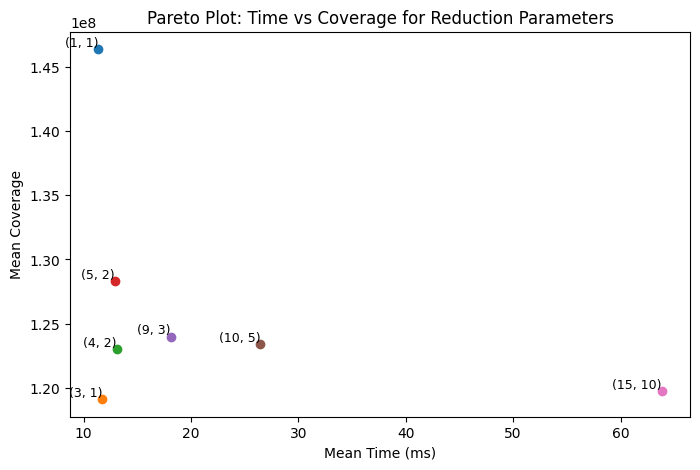

In [196]:
plt.subplots(1, 1, figsize=(8, 5))

for i, red in enumerate(reds):
    subdf = df[df["reduce_triggerSz_sizeLim_tuple"] == red]
    mean_time = subdf['sum_time_mean'].mean()
    mean_cover = subdf['result_coverage_mean'].mean()
    
    plt.scatter(mean_time, mean_cover)
    plt.text(mean_time, mean_cover, str(red), fontsize=9, ha='right', va='bottom')

plt.xlabel("Mean Time (ms)")
plt.ylabel("Mean Coverage")
plt.title("Pareto Plot: Time vs Coverage for Reduction Parameters")
plt.grid(True, alpha=0.0)
plt.savefig('/Users/asxvi/Desktop/uic/research/audb/extension/c_extension/tests/graphics/pareto.jpg')
plt.show()

### 